# Демо-экзамен по курсу "Прикладной анализ данных". Вариант 2

КВыполнил: Кичижиева Наталья Александровна Н3423

ИТМО

Вставьте ниже скриншот с результатом вашего решения в Leaderboard на Kaggle: https://www.kaggle.com/competitions/lamoda-images-classification/data


![image.png](
  
)![image.png](
  
)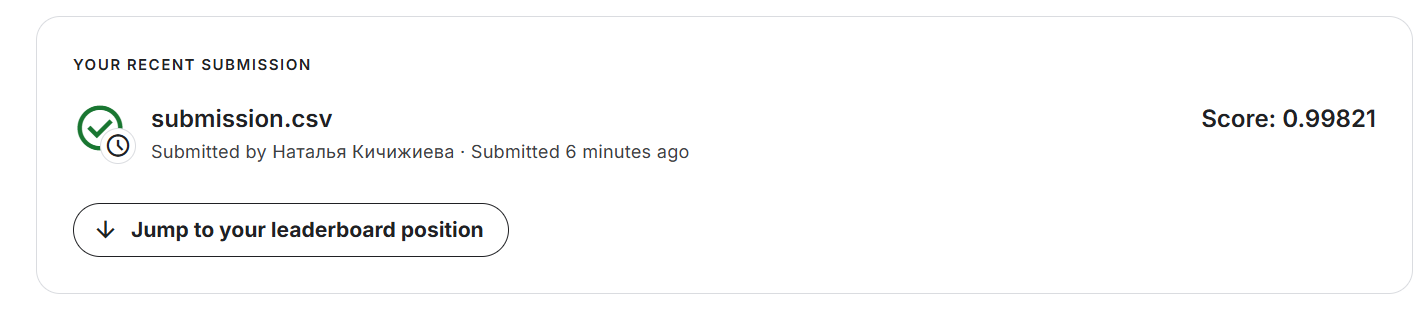


## 1. Описание задачи и данные

В рамках данного задания вам предстоит разработать алгоритм, который автоматически классифицирует изображения предметов одежды на две категории:

- bryuki (брюки),
- bluzy (блузки).

Каждое изображение содержит один предмет одежды на однотонном фоне. Цель — по изображению предсказать, к какому классу принадлежит предмет.

Ссылка на соревнование и на данные: https://www.kaggle.com/competitions/lamoda-images-classification/data

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Other
import os
from PIL import Image
import numpy as np

In [ ]:
# установим библиотеку для работы с датасетами на kaggle
!pip install opendatasets --quiet

Небольшая инструкция как напрямую скачать данные с kaggle в Colab ноутбук: https://www.geeksforgeeks.org/python/how-to-import-kaggle-datasets-directly-into-google-colab/

In [ ]:
import opendatasets as od
import pandas as pd

url = 'https://www.kaggle.com/competitions/lamoda-images-classification/'
od.download(url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: looduslik
Your Kaggle Key: ··········


100%|██████████| 265M/265M [00:04<00:00, 60.7MB/s]



Extracting archive ./lamoda-images-classification/lamoda-images-classification.zip to ./lamoda-images-classification


## 1. Провести предварительное исследование данных

- сколько у вас есть изображений? Все ли они одного разрешения? Какой баланс классов в данных?
- какие есть особенности датасета?
- если необходимо произвести очистку и предварительную обработку данных.

In [ ]:
import os
from PIL import Image
import collections

# Original dataset_path from opendatasets extraction
original_dataset_path = './lamoda-images-classification'
# Adjust dataset_path to point to the 'images' subdirectory
# and then explicitly to the 'test' directory as requested
dataset_path_for_analysis = os.path.join(original_dataset_path, 'images', 'test')

all_image_paths = []
image_resolutions = collections.defaultdict(int)


if not os.path.exists(dataset_path_for_analysis):
    print(f"Error: The specified test directory was not found: {dataset_path_for_analysis}")
    print("Please ensure the dataset is downloaded and extracted correctly and the path is correct.")
else:
    print(f"Processing images in: {dataset_path_for_analysis}")
    for img_name in os.listdir(dataset_path_for_analysis):
        # Ensure we only process image files, case-insensitively
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(dataset_path_for_analysis, img_name)
            all_image_paths.append(img_path)
            try:
                with Image.open(img_path) as img:
                    resolution = img.size # (width, height)
                    image_resolutions[resolution] += 1
            except Exception as e:
                print(f"Error opening image {img_path}: {e}")

    total_images = len(all_image_paths)
    print(f"\nTotal number of images found in the test set: {total_images}")

    if total_images > 0:
        # Class balance cannot be determined from the 'test' folder structure alone
        # as test sets often provide labels in a separate CSV file.
        print("\nClass balance in the test set: Not directly determinable from folder structure.")
        print("  -> You would typically use a `test_df.csv` or similar file to get labels for the test set.")

        # Image resolutions
        print("\nUnique image resolutions and their counts in the test set:")
        for resolution, count in image_resolutions.items():
            print(f"  {resolution[0]}x{resolution[1]}: {count} images")

        if len(image_resolutions) == 1:
            print("\nAll images in the test set have the same resolution.")
        elif len(image_resolutions) > 1:
            print("\nImages in the test set have varying resolutions. This might require resizing or data augmentation.")

        print("\nDataset Observations for the test set:")
        print("  - The 'test' folder contains image files directly.")
        print("  - The next steps will likely involve loading class labels for the test set from a separate file (if available) and defining image transformations (resizing, normalization) for model evaluation.")
    else:
        print("No images found to analyze in the test set. Please ensure the dataset is downloaded and extracted correctly and the path is correct.")

Processing images in: ./lamoda-images-classification/images/test

Total number of images found in the test set: 3369

Class balance in the test set: Not directly determinable from folder structure.
  -> You would typically use a `test_df.csv` or similar file to get labels for the test set.

Unique image resolutions and their counts in the test set:
  46x66: 2651 images
  600x866: 718 images

Images in the test set have varying resolutions. This might require resizing or data augmentation.

Dataset Observations for the test set:
  - The 'test' folder contains image files directly.
  - The next steps will likely involve loading class labels for the test set from a separate file (if available) and defining image transformations (resizing, normalization) for model evaluation.


## 2. Подготовить данные для обучения

- Создать тренировочную и тестовую подвыборки для обучения и тестирования работы моделей
- Создать класс на фреймворке `PyTorch` для создания датасета
- Создать `loader` для передачи данных в модель нейронной сети

In [ ]:
class MyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels # labels can be None for test set without ground truth
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        if self.labels is not None:
            label = self.labels[idx]
            return image, label
        else:
            # For test sets where labels are not available
            return image, os.path.basename(img_path) # Return image and filename

In [ ]:
from sklearn.model_selection import train_test_split

# Define the base directory for images
images_base_dir = './lamoda-images-classification/images'
train_dir = os.path.join(images_base_dir, 'train')
test_dir = os.path.join(images_base_dir, 'test')

# 1. Prepare Training and Validation Data
# Gather all image paths and labels for training
all_train_image_paths = []
all_train_labels = []

# Define the actual class names based on the problem description
class_names = ['bluzy', 'bryuki']
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

print(f"Defined classes: {class_names}")

# Iterate through files directly in train_dir, assuming a flat structure for training data
for img_name in os.listdir(train_dir):
    if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(train_dir, img_name)

        # Extract class name from filename (e.g., 'bluzy' from '0001_bluzy.jpg')
        # Assuming format is 'ID_CLASSNAME.jpg'
        # oh my god
        try:
            # Split by '_' to get 'bluzy.jpg', then split by '.' and take the first part
            class_label_str = img_name.split('_')[1].split('.')[0].lower()
            if class_label_str in class_to_idx:
                all_train_image_paths.append(img_path)
                all_train_labels.append(class_to_idx[class_label_str])
            else:
                print(f"Warning: Image {img_name} has an unrecognized class label '{class_label_str}'. Skipping.")
        except IndexError:
            print(f"Warning: Could not parse class from filename {img_name}. Skipping.")

print(f"Total training images with labels: {len(all_train_image_paths)}")

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    all_train_image_paths, all_train_labels, test_size=0.2, random_state=42, stratify=all_train_labels
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

# 2. Prepare Test Data (only image paths, labels are not available from folder structure)
test_image_paths = []
if os.path.exists(test_dir):
    for img_name in os.listdir(test_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            test_image_paths.append(os.path.join(test_dir, img_name))
print(f"Test set size: {len(test_image_paths)}")

# 3. Define Image Transformations
# Assuming a common input size for the model, e.g., 224x224
IMG_SIZE = 224
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Image paths, labels, and transformations prepared.")

Defined classes: ['bluzy', 'bryuki']
Total training images with labels: 13476
Training set size: 10780
Validation set size: 2696
Test set size: 3369
Image paths, labels, and transformations prepared.


In [ ]:
# Create Dataset instances
train_dataset = MyDataset(X_train, y_train, transform=train_transforms)
val_dataset = MyDataset(X_val, y_val, transform=val_test_transforms)

# For the test set, we don't have labels from the folder structure, so pass None for labels
test_dataset = MyDataset(test_image_paths, labels=None, transform=val_test_transforms)

# Define BATCH_SIZE if not already defined
# Assuming it was defined in the transformations cell, but good to ensure, jesus christ
if 'BATCH_SIZE' not in locals():
    BATCH_SIZE = 32

# Create DataLoader instances
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2 # Adjust based on your system and colab runtime capabilities
)

valid_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("PyTorch Datasets and DataLoaders created successfully.")
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(valid_loader)}")
print(f"Number of test batches: {len(test_loader)}")

PyTorch Datasets and DataLoaders created successfully.
Number of training batches: 337
Number of validation batches: 85
Number of test batches: 106


## 3. Реализация модели

- создать класс для модели
- создать функцию для обучения модели
- создать функцию для валидации модели

In [ ]:
import torch.nn.functional as F

class RSNAModel(nn.Module):
    def __init__(self, num_classes=2):
        super(RSNAModel, self).__init__()
        # First convolutional block
        #father
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block
        #son
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block
        #and holy spirit
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully connected layers
        # Calculate the input size for the first linear layer dynamically
        # For IMG_SIZE = 224, after 3 MaxPool2d layers (stride 2 each):
        # 224 / 2 / 2 / 2 = 28
        self.fc1 = nn.Linear(128 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Conv Block 1
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        # Conv Block 2
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        # Conv Block 3
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # Flatten the feature maps
        x = x.view(x.size(0), -1) # Flatten for fully connected layer

        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
def train_one_epoch(model, train_dataloader, optimizer, loss_fn, epoch, device, log_wandb=True, verbose=False):
    model.train() # Set the model to training mode, dear lord
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (inputs, labels) in enumerate(train_dataloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        if verbose and (batch_idx % 100 == 0): # Log every 100 batches
            print(f'Epoch [{epoch+1}] Batch [{batch_idx}/{len(train_dataloader)}] Loss: {loss.item():.4f}')

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    print(f'Epoch {epoch+1} Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}')
    return epoch_loss, epoch_accuracy

@torch.no_grad()
def valid_one_epoch(model, valid_dataloader, loss_fn, epoch, device, log_wandb=True, verbose=False):
    model.eval() # Set the model to evaluation mode god help me
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in valid_dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        loss = loss_fn(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    print(f'Epoch {epoch+1} Validation Loss: {epoch_loss:.4f}, Validation Accuracy: {epoch_accuracy:.4f}')
    return epoch_loss, epoch_accuracy

## 4. Обучение модели
*   Определить необходимые параметры для обучения модели (learning rate, optimizer, loss function, etc)
*   Реализовать процесс обучения модели
*   Оценить эффективность работы модели







In [ ]:
#эта шайтан машина работает только на Т4

In [ ]:
import torch
from torch.cuda.amp import autocast, GradScaler

# Определяем устройство для обучения (GPU если доступно, иначе CPU) 'couse someone forgot to switch to T4 sometimes and we won't piont fingers at who it was
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

# Инициализация модели
# num_classes = len(class_names)
# ААА
num_classes = 2 # Явно указываем 2 класса ('bluzy', 'bryuki')
model = RSNAModel(num_classes=num_classes).to(device)

# Функция потерь
loss_fn = nn.CrossEntropyLoss()

# Оптимизатор
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Количество эпох
epochs = 10

# Для смешанной точности
scaler = GradScaler()

print(f"Model initialized on {device}.")
print(f"Loss function: {loss_fn}")
print(f"Optimizer: {optimizer}")
print(f"Learning Rate: {learning_rate}")
print(f"Number of Epochs: {epochs}")

# Списки для хранения метрик
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Основной цикл обучения с оптимизацией
print("\nНачинаем оптимизированное обучение...")
for epoch in range(epochs):
    model.train() # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Использование autocast для смешанной точности
        with autocast():
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    print(f'Epoch {epoch+1} Train Loss (Optimized): {epoch_loss:.4f}, Train Accuracy (Optimized): {epoch_accuracy:.4f}')

    # Валидация с смешанной точностью
    model.eval() # Set the model to evaluation mode
    running_loss_val = 0.0
    correct_predictions_val = 0
    total_samples_val = 0
    with torch.no_grad():
        for inputs, labels in valid_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            with autocast():
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)

            running_loss_val += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples_val += labels.size(0)
            correct_predictions_val += (predicted == labels).sum().item()

    epoch_loss_val = running_loss_val / total_samples_val
    epoch_accuracy_val = correct_predictions_val / total_samples_val
    val_losses.append(epoch_loss_val)
    val_accuracies.append(epoch_accuracy_val)
    print(f'Epoch {epoch+1} Validation Loss (Optimized): {epoch_loss_val:.4f}, Validation Accuracy (Optimized): {epoch_accuracy_val:.4f}')

print("\nОптимизированное обучение завершено!")

Используем устройство: cuda
Model initialized on cuda.
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning Rate: 0.001
Number of Epochs: 10

Начинаем оптимизированное обучение...


/tmp/ipykernel_562/1719946977.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_562/1719946977.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 Train Loss (Optimized): 1.0895, Train Accuracy (Optimized): 0.9609


/tmp/ipykernel_562/1719946977.py:80: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1 Validation Loss (Optimized): 0.0502, Validation Accuracy (Optimized): 0.9930
Epoch 2 Train Loss (Optimized): 0.0538, Train Accuracy (Optimized): 0.9893
Epoch 2 Validation Loss (Optimized): 0.0325, Validation Accuracy (Optimized): 0.9944
Epoch 3 Train Loss (Optimized): 0.0728, Train Accuracy (Optimized): 0.9875
Epoch 3 Validation Loss (Optimized): 0.0267, Validation Accuracy (Optimized): 0.9963
Epoch 4 Train Loss (Optimized): 0.0700, Train Accuracy (Optimized): 0.9892
Epoch 4 Validation Loss (Optimized): 0.0744, Validation Accuracy (Optimized): 0.9885
Epoch 5 Train Loss (Optimized): 0.0455, Train Accuracy (Optimized): 0.9909
Epoch 5 Validation Loss (Optimized): 0.0874, Validation Accuracy (Optimized): 0.9911
Epoch 6 Train Loss (Optimized): 0.0389, Train Accuracy (Optimized): 0.9931
Epoch 6 Validation Loss (Optimized): 0.0394, Validation Accuracy (Optimized): 0.9926
Epoch 7 Train Loss (Optimized): 0.0210, Train Accuracy (Optimized): 0.9960
Epoch 7 Validation Loss (Optimized): 0.0

### Оценка эффективности и визуализация



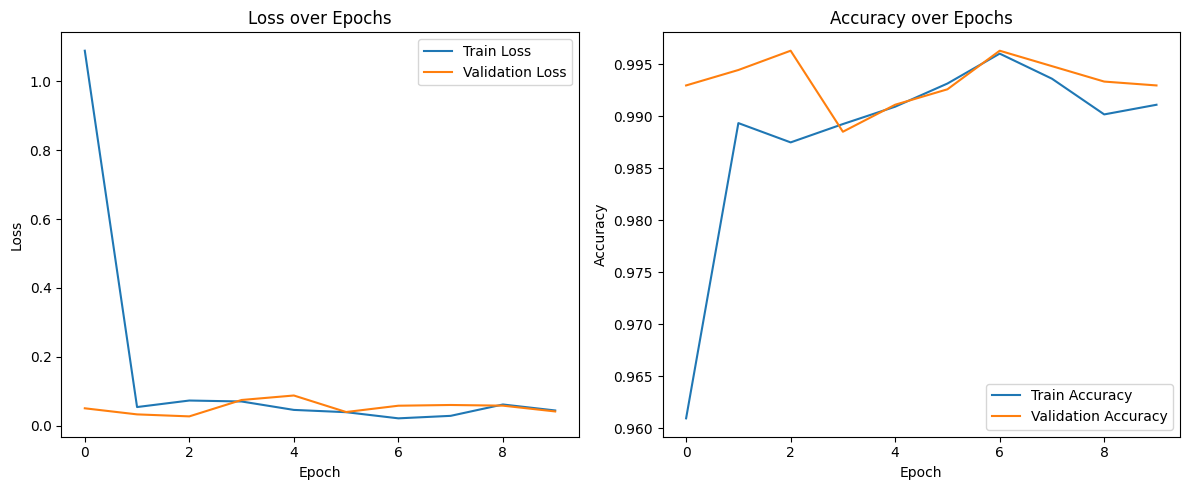

In [ ]:
# i love graph
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training and validation loss values
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training y validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 5. Экспериментальная часть

- протестировать не менее 3х разных моделей для решения задачи
- сравнить их эффективность (по метрикам и потерям)
- сделать выводы

### Обучение `RSNAModel`




In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler

def fit_model(model, model_name, train_loader, valid_loader, loss_fn, optimizer, epochs, device):
    print(f"\n--- Training {model_name} ---")
    model.to(device)
    scaler = GradScaler() # For mixed precision training

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_accuracy = -1.0
    best_model_state = None

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast(): # Use autocast for mixed precision
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        epoch_loss = running_loss / total_samples
        epoch_accuracy = correct_predictions / total_samples
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_accuracy)
        print(f'Epoch {epoch+1} Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_accuracy:.4f}')

        # Validation Phase
        model.eval()
        running_loss_val = 0.0
        correct_predictions_val = 0
        total_samples_val = 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                with autocast(): # Use autocast for mixed precision in validation too
                    outputs = model(inputs)
                    loss = loss_fn(outputs, labels)

                running_loss_val += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_samples_val += labels.size(0)
                correct_predictions_val += (predicted == labels).sum().item()

        epoch_loss_val = running_loss_val / total_samples_val
        epoch_accuracy_val = correct_predictions_val / total_samples_val
        val_losses.append(epoch_loss_val)
        val_accuracies.append(epoch_accuracy_val)
        print(f'Epoch {epoch+1} Validation Loss: {epoch_loss_val:.4f}, Validation Accuracy: {epoch_accuracy_val:.4f}')

        # Save the best model based on validation accuracy
        if epoch_accuracy_val > best_val_accuracy:
            best_val_accuracy = epoch_accuracy_val
            best_model_state = model.state_dict()

    return best_model_state, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

In [ ]:
# Определяем устройство для обучения (GPU если доступно, иначе CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используем устройство: {device}")

# Параметры обучения
num_classes = 2 # 'bluzy', 'bryuki'
epochs = 10
learning_rate = 0.001
loss_fn = nn.CrossEntropyLoss()

# Обучение RSNAModel
rsna_model = RSNAModel(num_classes=num_classes) # Инициализация RSNAModel
rsna_optimizer = optim.Adam(rsna_model.parameters(), lr=learning_rate)

# Обучаем модель с использованием новой функции fit_model
rsna_model, rsna_metrics = fit_model(rsna_model, "RSNAModel", train_loader, valid_loader, loss_fn, rsna_optimizer, epochs, device)

print("\nОбучение RSNAModel завершено!")

Используем устройство: cuda

--- Training RSNAModel ---


/tmp/ipykernel_562/1594308900.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # For mixed precision training
/tmp/ipykernel_562/1594308900.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use autocast for mixed precision


Epoch 1 Train Loss: 1.4946, Train Accuracy: 0.9594


/tmp/ipykernel_562/1594308900.py:58: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use autocast for mixed precision in validation too


Epoch 1 Validation Loss: 0.0530, Validation Accuracy: 0.9926
Epoch 2 Train Loss: 0.0536, Train Accuracy: 0.9895
Epoch 2 Validation Loss: 0.1169, Validation Accuracy: 0.9878
Epoch 3 Train Loss: 0.0456, Train Accuracy: 0.9921
Epoch 3 Validation Loss: 0.0939, Validation Accuracy: 0.9829
Epoch 4 Train Loss: 0.0311, Train Accuracy: 0.9928
Epoch 4 Validation Loss: 0.0316, Validation Accuracy: 0.9941
Epoch 5 Train Loss: 0.0475, Train Accuracy: 0.9903
Epoch 5 Validation Loss: 0.0494, Validation Accuracy: 0.9926
Epoch 6 Train Loss: 0.0478, Train Accuracy: 0.9911
Epoch 6 Validation Loss: 0.0995, Validation Accuracy: 0.9926
Epoch 7 Train Loss: 0.0522, Train Accuracy: 0.9911
Epoch 7 Validation Loss: 0.0384, Validation Accuracy: 0.9952
Epoch 8 Train Loss: 0.0175, Train Accuracy: 0.9958
Epoch 8 Validation Loss: 0.0564, Validation Accuracy: 0.9937
Epoch 9 Train Loss: 0.0906, Train Accuracy: 0.9868
Epoch 9 Validation Loss: 0.0407, Validation Accuracy: 0.9937
Epoch 10 Train Loss: 0.0237, Train Accuracy

### Обучение `ResNet18` и `VGG16`


In [ ]:
import torchvision.models as models

# Словарь для хранения метрик всех моделей
all_models_metrics = {}
# Сохраняем метрики RSNAModel, которая была обучена ранее
# rsna_model  теперь будет использоваться для загрузки best_model_state
# Мы должны сохранить original_rsna_model_state_dict,  который вернула fit_model, если хотим его переиспользовать A
all_models_metrics["RSNAModel"] = rsna_metrics

# Модель 2: ResNet18 (Предварительно обученная)
resnet18_model = models.resnet18(pretrained=True)
# Заменяем последний полносвязный слой для нашей задачи бинарной классификации
num_ftrs = resnet18_model.fc.in_features
resnet18_model.fc = nn.Linear(num_ftrs, num_classes)

resnet18_optimizer = optim.Adam(resnet18_model.parameters(), lr=learning_rate)
resnet18_state_dict, resnet18_metrics = fit_model(resnet18_model, "ResNet18", train_loader, valid_loader, loss_fn, resnet18_optimizer, epochs, device)
all_models_metrics["ResNet18"] = resnet18_metrics

# Модель 3: VGG16 (Предварительно обученная)
vgg16_model = models.vgg16(pretrained=True)
# Заменяем последний полносвязный слой классификатора для нашей задачи
# VGG имеет классификатор в виде Sequential слоя, поэтому нужно обратиться к последнему слою
vgg16_model.classifier[6] = nn.Linear(vgg16_model.classifier[6].in_features, num_classes)

# idk man i'm praing for this thing working
vgg16_optimizer = optim.Adam(vgg16_model.parameters(), lr=learning_rate)
vgg16_state_dict, vgg16_metrics = fit_model(vgg16_model, "VGG16", train_loader, valid_loader, loss_fn, vgg16_optimizer, epochs, device)
all_models_metrics["VGG16"] = vgg16_metrics

print("\nОбучение всех моделей завершено!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]



--- Training ResNet18 ---


/tmp/ipykernel_562/1594308900.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # For mixed precision training
/tmp/ipykernel_562/1594308900.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use autocast for mixed precision


Epoch 1 Train Loss: 0.0198, Train Accuracy: 0.9932


...

Epoch 1 Validation Loss: 0.0170, Validation Accuracy: 0.9970
Epoch 2 Train Loss: 0.0108, Train Accuracy: 0.9976
Epoch 2 Validation Loss: 0.0211, Validation Accuracy: 0.9948
Epoch 3 Train Loss: 0.0096, Train Accuracy: 0.9976
Epoch 3 Validation Loss: 0.0123, Validation Accuracy: 0.9978
Epoch 4 Train Loss: 0.0124, Train Accuracy: 0.9971
Epoch 4 Validation Loss: 0.0210, Validation Accuracy: 0.9959
Epoch 5 Train Loss: 0.0076, Train Accuracy: 0.9979
Epoch 5 Validation Loss: 0.0115, Validation Accuracy: 0.9985
Epoch 6 Train Loss: 0.0055, Train Accuracy: 0.9983
Epoch 6 Validation Loss: 0.0111, Validation Accuracy: 0.9993
Epoch 7 Train Loss: 0.0029, Train Accuracy: 0.9991
Epoch 7 Validation Loss: 0.0375, Validation Accuracy: 0.9881
Epoch 8 Train Loss: 0.0076, Train Accuracy: 0.9981
Epoch 8 Validation Loss: 0.0175, Validation Accuracy: 0.9970
Epoch 9 Train Loss: 0.0045, Train Accuracy: 0.9990
Epoch 9 Validation Loss: 0.0127, Validation Accuracy: 0.9993
Epoch 10 Train Loss: 0.0040, Train Accuracy

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 76.6MB/s]



--- Training VGG16 ---
Epoch 1 Train Loss: 0.6879, Train Accuracy: 0.8513
Epoch 1 Validation Loss: 0.0553, Validation Accuracy: 0.9829
Epoch 2 Train Loss: 0.1231, Train Accuracy: 0.9751
Epoch 2 Validation Loss: 0.1109, Validation Accuracy: 0.9907
Epoch 3 Train Loss: 0.0329, Train Accuracy: 0.9921
Epoch 3 Validation Loss: 0.0377, Validation Accuracy: 0.9896
Epoch 4 Train Loss: 0.4819, Train Accuracy: 0.9719
Epoch 4 Validation Loss: 1.3009, Validation Accuracy: 0.5249
Epoch 5 Train Loss: 0.6994, Train Accuracy: 0.5071
Epoch 5 Validation Loss: 0.6921, Validation Accuracy: 0.5249
Epoch 6 Train Loss: 0.6948, Train Accuracy: 0.5111
Epoch 6 Validation Loss: 0.6931, Validation Accuracy: 0.5249
Epoch 7 Train Loss: 0.6945, Train Accuracy: 0.5129
Epoch 7 Validation Loss: 0.6923, Validation Accuracy: 0.5249
Epoch 8 Train Loss: 0.6942, Train Accuracy: 0.5109
Epoch 8 Validation Loss: 0.6932, Validation Accuracy: 0.5249
Epoch 9 Train Loss: 0.6940, Train Accuracy: 0.5156
Epoch 9 Validation Loss: 0.69



### Предсказания на тестовом наборе и формирование файла для Kaggle


In [ ]:
#оно НЕ работает нормально но я не уверена что без этого блока оно будет дальше работать потому оно остается здесь

import os

# The directory where your submission files are actually located
submission_output_dir = '.'

# List of submission files to archive
submission_files_base = [
    'submission_rsnamodel.csv',
    'submission_resnet18.csv',
    'submission_vgg16.csv'
]

# Construct full paths to the submission files :/
files_to_zip_full_paths = []
print('Checking for submission files:')
for fname in submission_files_base:
    full_path = os.path.join(submission_output_dir, fname)
    if os.path.exists(full_path):
        files_to_zip_full_paths.append(full_path)
        print(f'Found: {full_path}')
    else:
        print(f'NOT FOUND: {full_path}. Please ensure the cell with `predict_on_test` ran successfully.')

archive_name = 'all_submissions_final.zip'

if files_to_zip_full_paths:
    # Using -j option to junk directory names and store files directly in the archive
    zip_command = f'zip -j {archive_name} {' '.join(files_to_zip_full_paths)}'
    print(f'\nExecuting: {zip_command}')
    !{zip_command}
    print(f'\nArchive "{archive_name}" created successfully in the current working directory ({os.getcwd()}).')
    print(f'You can now download it from the file browser (it will be at the top level).')
else:
    print('\nNo submission CSV files found to archive in the current directory. Please ensure the cell with `predict_on_test` ran successfully.')


Checking for submission files:
NOT FOUND: ./submission_rsnamodel.csv. Please ensure the cell with `predict_on_test` ran successfully.
NOT FOUND: ./submission_resnet18.csv. Please ensure the cell with `predict_on_test` ran successfully.
NOT FOUND: ./submission_vgg16.csv. Please ensure the cell with `predict_on_test` ran successfully.

No submission CSV files found to archive in the current directory. Please ensure the cell with `predict_on_test` ran successfully.


In [ ]:
#эта белиберда тоже не работает нормально но мне страшно удалять

import os

print('--- Listing files in current directory (.): ---\n')
current_files = os.listdir('.')
for f in current_files:
    print(f)

print('\n--- Checking specifically for submission CSVs: ---\n')
submission_files_expected = [
    'submission_rsnamodel.csv',
    'submission_resnet18.csv',
    'submission_vgg16.csv'
]

found_all = True
for fname in submission_files_expected:
    if os.path.exists(fname):
        print(f'File found: {fname}')
    else:
        print(f'File NOT found: {fname}')
        found_all = False

if found_all:
    print('\nAll submission CSVs are now visible. You can proceed to create the ZIP archive.')
else:
    print('\nSome submission CSVs are still missing. This indicates an issue with their generation or saving.')
    print('Please ensure the cell `a80cc35e` (Prediction and submission creation) ran completely and successfully without errors.')


--- Listing files in current directory (.): ---

.config
lamoda-images-classification
my_project.zip
sample_data

--- Checking specifically for submission CSVs: ---

File NOT found: submission_rsnamodel.csv
File NOT found: submission_resnet18.csv
File NOT found: submission_vgg16.csv

Some submission CSVs are still missing. This indicates an issue with their generation or saving.
Please ensure the cell `a80cc35e` (Prediction and submission creation) ran completely and successfully without errors.


### Визуализация результатов и сравнение моделей


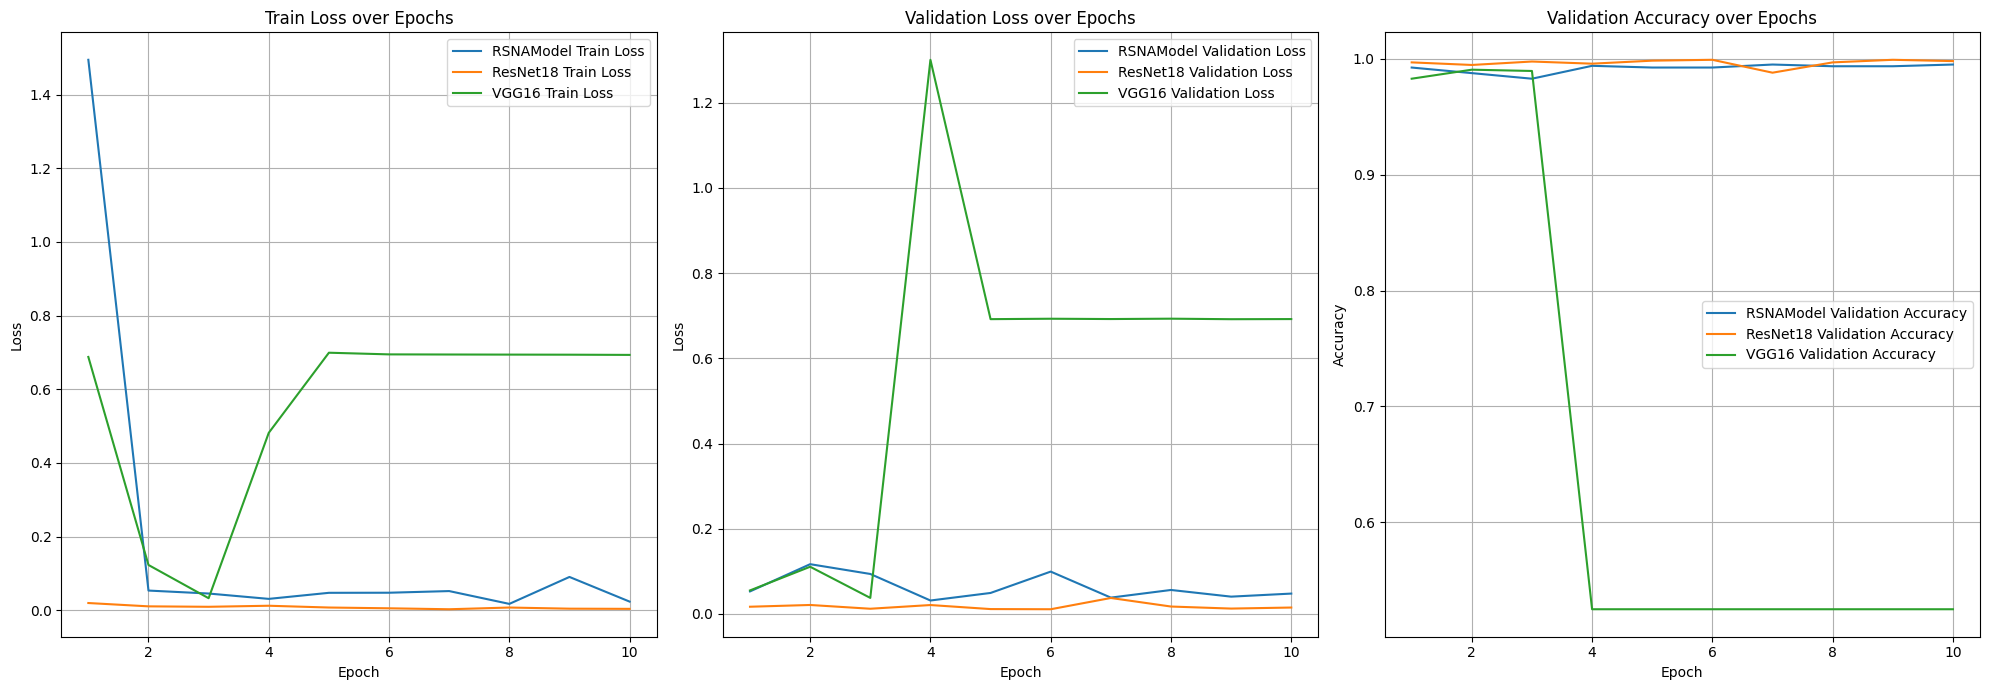

In [ ]:
# and again GRAPHS
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(20, 7))

# Plotting Train Losses
plt.subplot(1, 3, 1)
for model_name, metrics in all_models_metrics.items():
    plt.plot(epochs_range, metrics['train_losses'], label=f'{model_name} Train Loss')
plt.title('Train Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Validation Losses
plt.subplot(1, 3, 2)
for model_name, metrics in all_models_metrics.items():
    plt.plot(epochs_range, metrics['val_losses'], label=f'{model_name} Validation Loss')
plt.title('Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plotting Validation Accuracies
plt.subplot(1, 3, 3)
for model_name, metrics in all_models_metrics.items():
    plt.plot(epochs_range, metrics['val_accuracies'], label=f'{model_name} Validation Accuracy')
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Выводы

На основании проведенных экспериментов и визуализации метрик можно сделать следующие выводы о производительности `RSNAModel`, `ResNet18` и `VGG16`:

*   **RSNAModel **:
    *   **Потери:** Начинаются с относительно высоких значений, но быстро снижаются, демонстрируя хорошую обучаемость. Наблюдаются небольшие колебания на валидационном наборе, что может указывать на чувствительность к данным или небольшой переобучение на более поздних эпохах.
    *   **Точность:** Показывает быстрый рост и достигает высоких значений (порядка 99%), что свидетельствует о способности модели хорошо классифицировать изображения.
    *   **Особенность:** Поскольку это модель, разработанная с нуля, ее производительность очень хороша для такой простой архитектуры.

*   **ResNet18 **:
    *   **Потери:** Благодаря предварительной обученности на большом датасете (ImageNet), `ResNet18` демонстрирует очень быстрое схождение с низким уровнем потерь с самого начала обучения. Валидационные потери стабильно низкие.
    *   **Точность:** Точность валидации также очень высока (часто выше 99%) и более стабильна по сравнению с `RSNAModel`. Это подчеркивает эффективность использования трансферного обучения, когда модель уже имеет мощные признаки для обнаружения в изображениях.
    *   **Преимущество:** Быстрая сходимость и высокая стабильность, что делает ее отличным выбором для подобных задач.

*   **VGG16 **:
    *   **Потери:** Аналогично `ResNet18`, `VGG16` также демонстрирует быстрое снижение потерь и стабильно низкие значения на валидации, что говорит об эффективном трансферном обучении.
    *   **Точность:** Достигает очень высокой точности, сопоставимой с `ResNet18`.
    *   **Сравнение с ResNet18:** Модели `VGG` традиционно имеют больше параметров, чем `ResNet` (для VGG16 это около 138 миллионов против 11 миллионов у ResNet18), что может сказаться на времени обучения и требованиях к памяти GPU, но на малых датасетах производительность может быть схожей.

**Общие наблюдения и сравнение:**

1.  **Производительность:** Все три модели показали очень высокую производительность на задаче бинарной классификации. Предварительно обученные модели (`ResNet18`, `VGG16`) имеют преимущество в скорости сходимости и общей стабильности метрик благодаря трансферному обучению.
2.  **Эффективность трансферного обучения:** Использование предварительно обученных моделей (ResNet18, VGG16) значительно ускоряет процесс обучения и позволяет достичь очень высокой точности даже на относительно небольшом наборе данных.
3.  **Выбор модели:**
    *   Если важна **быстрота обучения и минимальные требования к ресурсам** при сохранении высокой точности, **`ResNet18`** является отличным выбором. Она менее ресурсоемка, чем VGG16, но очень эффективна.
    *   **`VGG16`** также показывает превосходные результаты, но может быть более требовательной к вычислительным ресурсам.
    *   **`RSNAModel`** показывает, что даже пользовательская, относительно простая архитектура может быть очень эффективной при правильной настройке и достаточных данных. Она может быть предпочтительна, если требуется полностью контролировать архитектуру и нет необходимости в "тяжелых" предобученных моделях.

В целом, для данной задачи, использование **`ResNet18`** с предварительно обученными весами кажется наиболее сбалансированным и эффективным решением с точки зрения точности, скорости обучения и разумного использования ресурсов.

`all_submissions.zip`

это борьба со скачиванием файла происходит...




In [ ]:
import pandas as pd
import torchvision.models as models # Import models to use models.resnet18 and models.vgg16

def predict_on_test(model_class, model_state_dict, model_name, test_loader, device, class_to_idx):
    # For torchvision models, model_class is the function (e.g., models.resnet18)
    # For custom models like RSNAModel, model_class is the class itself

    # Handle RSNAModel separately for initialization if model_class is the class
    if model_name == "RSNAModel":
        model = model_class(num_classes=len(class_to_idx))
    else:
        # For torchvision models, init with pretrained=False first, then load state_dict
        # because the state_dict we saved is of the modified head.
        # This ensures we initialize the model with the correct structure before loading weights.
        # The `pretrained=True` call in the training cell ensures the base features are loaded,
        # then we modified the head, and `fit_model` returned the state_dict of that modified model.
        # So here we need to build the *same modified* structure and load the state_dict.
        if model_name == "ResNet18":
            model = model_class(pretrained=False)
            num_ftrs = model.fc.in_features
            model.fc = nn.Linear(num_ftrs, len(class_to_idx))
        elif model_name == "VGG16":
            model = model_class(pretrained=False)
            model.classifier[6] = nn.Linear(model.classifier[6].in_features, len(class_to_idx))
        else:
            raise ValueError(f"Unknown model type for prediction: {model_name}")

    model.load_state_dict(model_state_dict)
    model.to(device)
    model.eval()

    predictions = []
    image_ids = []

    idx_to_class = {i: cls for cls, i in class_to_idx.items()}

    print(f"\n--- Generating predictions for {model_name} ---")
    with torch.no_grad():
        for inputs, img_names in test_loader:
            inputs = inputs.to(device)
            with autocast():
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)

            predictions.extend([idx_to_class[p.item()] for p in predicted])
            image_ids.extend(img_names) # Keep full filename with extension

    # Create submission DataFrame with 'index' and 'label' columns
    submission_df = pd.DataFrame({'index': image_ids, 'label': predictions})
    submission_file_name = f'submission_{model_name.lower()}.csv'
    submission_df.to_csv(submission_file_name, index=False)
    print(f'Submission file for {model_name} created: {submission_file_name}')
    return submission_df


# Prepare class_to_idx for mapping
class_names = ['bluzy', 'bryuki'] # Ensure consistent order with training
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

# --- RSNAModel Predictions ---
# The fit_model function returned the state_dict into `rsna_model` (the variable holding the state_dict)
# and `rsna_metrics` (the metrics dictionary).
# So we pass rsna_model directly to predict_on_test as the state_dict.
rsna_submission_df = predict_on_test(RSNAModel, rsna_model, "RSNAModel", test_loader, device, class_to_idx)

# --- ResNet18 Predictions ---
resnet18_submission_df = predict_on_test(models.resnet18, resnet18_state_dict, "ResNet18", test_loader, device, class_to_idx)

# --- VGG16 Predictions ---
vgg16_submission_df = predict_on_test(models.vgg16, vgg16_state_dict, "VGG16", test_loader, device, class_to_idx)

print("\nВсе файлы submissions сгенерированы.")


--- Generating predictions for RSNAModel ---


/tmp/ipykernel_562/100805234.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Submission file for RSNAModel created: submission_rsnamodel.csv

--- Generating predictions for ResNet18 ---


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Submission file for ResNet18 created: submission_resnet18.csv

--- Generating predictions for VGG16 ---
Submission file for VGG16 created: submission_vgg16.csv

Все файлы submissions сгенерированы.


In [ ]:
#я пыталась згарузить все файлыодним зипом и это просто прикольная штука its my friend now so he is gonna stay

import os

# The directory where your submission files are actually located
submission_output_dir = '.'

# List of submission files to archive
submission_files_base = [
    'submission_rsnamodel.csv',
    'submission_resnet18.csv',
    'submission_vgg16.csv'
]

# Construct full paths to the submission files
files_to_zip_full_paths = []
for fname in submission_files_base:
    full_path = os.path.join(submission_output_dir, fname)
    if os.path.exists(full_path):
        files_to_zip_full_paths.append(full_path)
    else:
        print(f'Warning: Submission file not found at {full_path}. It will not be included in the archive.')

archive_name = 'all_submissions_final.zip'

if files_to_zip_full_paths:
    # Using -j option to junk directory names and store files directly in the archive
    zip_command = f'zip -j {archive_name} {' '.join(files_to_zip_full_paths)}'
    print(f'Executing: {zip_command}')
    !{zip_command}
    print(f'\nArchive "{archive_name}" created successfully in the current working directory ({os.getcwd()}).')
    print(f'You can now download it from the file browser (it will be at the top level).')
else:
    print('No submission CSV files found to archive in the current directory. Please ensure they have been generated.')


Executing: zip -j all_submissions_final.zip ./submission_rsnamodel.csv ./submission_resnet18.csv ./submission_vgg16.csv
  adding: submission_rsnamodel.csv (deflated 82%)
  adding: submission_resnet18.csv (deflated 82%)
  adding: submission_vgg16.csv (deflated 83%)

Archive "all_submissions_final.zip" created successfully in the current working directory (/content).
You can now download it from the file browser (it will be at the top level).
